# Library Imports

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import pandas as pd
import numpy as np

import random
import time
import os

import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Dropout,Input,Flatten,Rescaling
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers,models,Input
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import ReduceLROnPlateau

<br>

# Dataset Visualization and analysis

### We will check the number of images in each folder and visualize the sample images

In [2]:
labels = []
class_names = ['COVID','Healthy','Pneumonia']
class_count = {}
total_image = 0

In [3]:
for category in class_names:
    folder_path = 'lung_dataset/'
    path = os.path.join(folder_path,category)
    files = os.listdir(path)
    count = len(files)
    class_count[category] = count
    total_image +=count
    labels.extend([category]*count)

print(f'Total images: {(total_image)}')
print(f'-----------------------------')
print('Images per class')
for cat,count in class_count.items():
    print(f'{cat}: {count}')

Total images: 15153
-----------------------------
Images per class
COVID: 3616
Healthy: 10192
Pneumonia: 1345


### This shows the imbalance in the dataset, healthy images outperform other two labels. This is a challange as the model is biased to the class with the highest number. We will deal with this  by adding class weights.

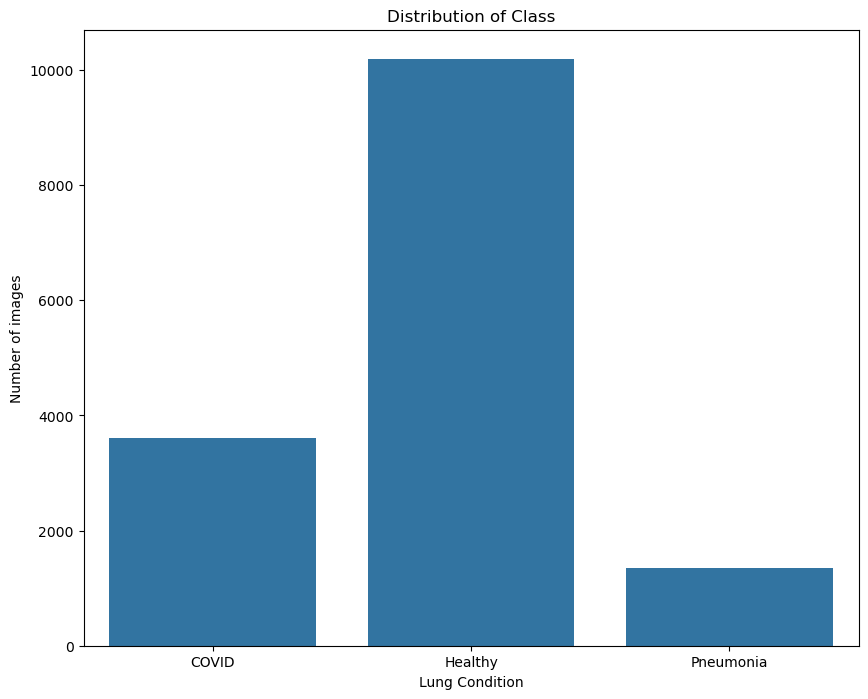

In [4]:
plt.figure(figsize=(10,8))
sns.countplot(x=labels)
plt.title('Distribution of Class')
plt.xlabel('Lung Condition')
plt.ylabel('Number of images');

In [5]:
random.randint(1,1000)

244

### The images show the variability in shape, contrast and alignment. So, we will have to standardise them.

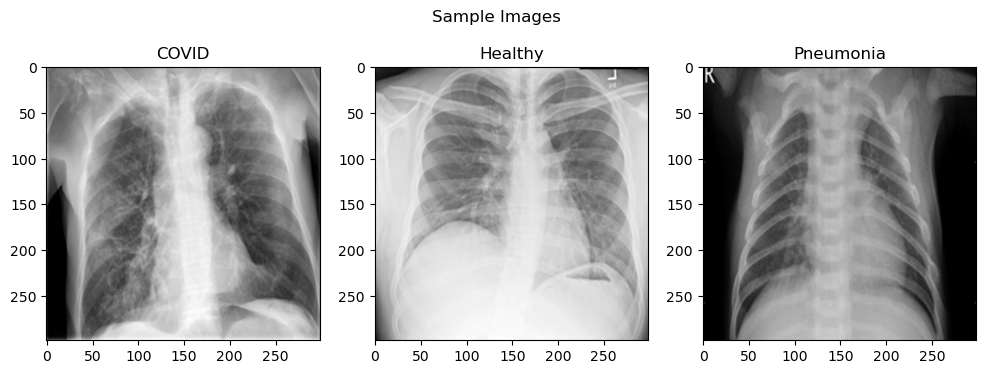

In [6]:
plt.figure(figsize=(12,4))
for i,category in enumerate(class_names):
    path = os.path.join('lung_dataset/',category)

    file_name = os.listdir(path)[random.randint(1,1000)]
    img_path = os.path.join(path,file_name)

    img = mpimg.imread(img_path)
    plt.subplot(1,3,i+1)
    plt.imshow(img,cmap='gray')
    plt.title(category)

plt.suptitle('Sample Images');

<br><br>

# Data Loading and Spitting
### Image Data Loading: https://keras.io/api/data_loading/image/

### We will split the data into train, validation and test. Then, we will train the model on the training data and validate with parameter tuning on the validation data. Finally, we will use the testing data as a final holdout dataset to test the model. After testing on the test data, we cannot change the parameter; it will be our final model.

In [7]:
DATA_DIR = 'lung_dataset/'

### The training data contaions 80% of the split with an image size of 180,180 and a batch size of 32. The shuffle is set to True by default, which will ensure images are shuffled. 
### The validation and test data contains 20% split, which are futher split into the validation and test data at a 50:50 ratio.

In [8]:
train_data = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed = 101,
    image_size= (180,180),
    batch_size = 32
)

Found 15153 files belonging to 3 classes.
Using 12123 files for training.


In [9]:
val_test_data = image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed = 101,
    image_size=(180,180),
    batch_size=32
)

Found 15153 files belonging to 3 classes.
Using 3030 files for validation.


In [10]:
train_data.class_names

['COVID', 'HEALTHY', 'PNEUMONIA']

In [11]:
val_test_data.class_names

['COVID', 'HEALTHY', 'PNEUMONIA']

### To further split the val_test data into testing and validation data, we will use tf.data.experimental.cardinality, which determines the number of total batches.
### Then we use .take() and .skip(). take() grabs the given batches and .skip() skips those batches and use rest of the batches. 
### Split data: https://stackoverflow.com/questions/48213766/split-a-dataset-created-by-tensorflow-dataset-api-in-to-train-and-test

In [12]:
from tensorflow.data import experimental

In [13]:
val_batch_count = experimental.cardinality(val_test_data)

### There are a total of 95 batches in the val_test dataset. Since we are splitting the data in the ratio 50:50 between validation and test. We first divide the total_batches by 2 and take the first 47 batches into the validation and the rest into the testing data.

In [14]:
val_batch_count

<tf.Tensor: shape=(), dtype=int64, numpy=95>

In [15]:
test_batch_count = val_batch_count//2

In [16]:
test_batch_count

<tf.Tensor: shape=(), dtype=int64, numpy=47>

In [17]:
val_data = val_test_data.take(test_batch_count)

In [18]:
test_data = val_test_data.skip(test_batch_count)

In [19]:
print(f'Validation Batches: {len(val_data)} and Number of images in Validation: {len(val_data)*32}')
print(f'Test Batches: {len(test_data)} and Number of images in test: {len(test_data)*32}')

Validation Batches: 47 and Number of images in Validation: 1504
Test Batches: 48 and Number of images in test: 1536


<br>

# Baseline Model 

### In the baseline model, we will build a base CNN model without any augmentation or weight adjustment. This will give us an idea about how the base CNN model performs on the dataset and serve as a benchmark for other models. 

In [20]:
image_shape = (180,180,3)

### First, we set the size of the image as (180,180,3) and rescale the image to normalise into the range [0,1]. This will increase the performance.
### Then we use the 2D convolutional network with 32 filters, kernel size of 3X3 and activation function of rectified linear unit. This is followed by the max polling layer of kernel size 2X2, which will downsample the images to reduce the computational cost.
### This is followed by another 2D convolutional network with 64 filters and a max pooling layer. 
### Finally, the model is flattened into a 1D vector and fed to the dense layer with 128 neurons, and the dropout is set to 0.5 to randomly turnoff 50% of neurons to prevent overfitting. This is followed by a final dense layer that outputs 3 neurons, one for each class, with softmax activation to output probabilities.
### The model is compiled using the Adam optimiser, and the loss is categorical cross-entropy as it is a multi-class classification.

In [21]:
base_model = Sequential()

base_model.add(Input(shape=image_shape))

base_model.add(Rescaling(1./255))

base_model.add(Conv2D(filters=32,kernel_size=(3,3),padding='same',activation='relu'))
base_model.add(MaxPool2D(pool_size=(2,2)))

base_model.add(Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'))
base_model.add(MaxPool2D(pool_size=(2,2)))


base_model.add(Flatten())
base_model.add(Dense(128,activation='relu'))
base_model.add(Dropout(0.5))


base_model.add(Dense(3,activation='softmax'))

base_model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

### The summary of the model shows that there are approximately 16 million trainable parameters for the base model. 

In [22]:
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 129600)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,588,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,608,707 (63.36 MB)

 Trainable params: 16,608,707 (63.36 MB)

 Non-trainable params: 0 (0.00 B)

### Early stopping prevents the model from overfitting. It monitors the validation loss, and if the validation loss does not go down for more than 2 epochs, then it will stop the training and take the best weights from the previous epoch that had the lowest validation loss. 

In [23]:
early_stopping = EarlyStopping(monitor='val_loss',
                              mode='min',
                              patience=2,
                              verbose=1,restore_best_weights=True)

### We keep track of the time to determine how much time the model took to train, which will also give us an idea of the efficiency of the model.
### We will fit the base model with training data and validation data to calculate the validation loss and validation accuracy for 20 epochs, and the callback is early stopping with a batch size of 32. 
### Batch size controls how many images the model processes before updating its weights. We set it to 32. If the batch size is too big, it will lead to generalisation, and if it is too small, it will take longer to train. 

In [24]:
start_time = time.time()

baseline_results= base_model.fit(train_data,epochs=20,
                           validation_data=val_data,
                           callbacks=[early_stopping],batch_size=32)

end_time = time.time()
time_taken = (end_time-start_time)/60
print(f'/n Total training time for base model: {time_taken:.2f} minutes')

Epoch 1/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 88s 230ms/step - accuracy: 0.7573 - loss: 0.7992 - val_accuracy: 0.9076 - val_loss: 0.2532
Epoch 2/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 87s 230ms/step - accuracy: 0.9126 - loss: 0.2365 - val_accuracy: 0.9322 - val_loss: 0.1919
Epoch 3/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 88s 233ms/step - accuracy: 0.9410 - loss: 0.1659 - val_accuracy: 0.9395 - val_loss: 0.1629
Epoch 4/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 88s 231ms/step - accuracy: 0.9557 - loss: 0.1202 - val_accuracy: 0.9528 - val_loss: 0.1448
Epoch 5/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 87s 230ms/step - accuracy: 0.9689 - loss: 0.0832 - val_accuracy: 0.9528 - val_loss: 0.1458
Epoch 6/20
379/379 ━━━━━━━━━━━━━━━━━━━━ 80s 210ms/step - accuracy: 0.9792 - loss: 0.0632 - val_accuracy: 0.9355 - val_loss: 0.2196
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 4.
/n Total training time for base model: 8.62 minutes


<br>

### Base model took around 9 minutes to train, and the weights from epoch 4 were taken as it had the lowest validation loss of 0.1448.

<br>

## Basemodel Evaluation

### We evaluated the model on the validation data, and it showed 94% accuracy and a loss of 16%. This is a very amazing result for the base model. But we have to plot the loss against the validation loss to check for overfitting and underfitting.  

In [25]:
base_model.evaluate(val_data)

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9455 - loss: 0.1609


[0.15155786275863647, 0.9468085169792175]

In [26]:
base_results = pd.DataFrame(base_model.history.history)

In [27]:
base_results

,accuracy,loss,val_accuracy,val_loss
0,0.826776,0.461314,0.907580,0.253165
1,0.919574,0.214968,0.932181,0.191867
2,0.945228,0.149102,0.939495,0.162867
3,0.958509,0.112727,0.952793,0.144768
4,0.971212,0.079370,0.952793,0.145791
5,0.977811,0.063440,0.935505,0.219609


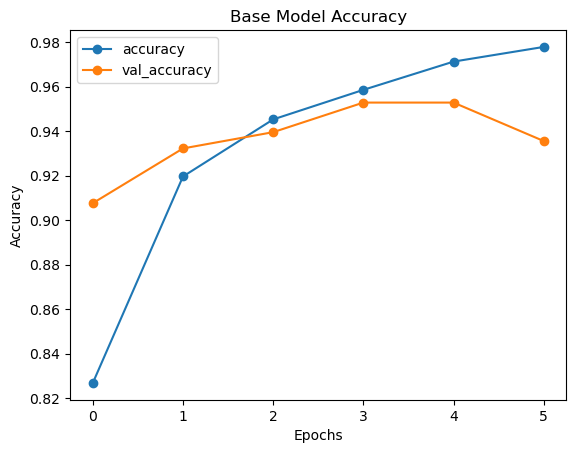

In [28]:
base_results[['accuracy','val_accuracy']].plot(marker='o')
plt.title('Base Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

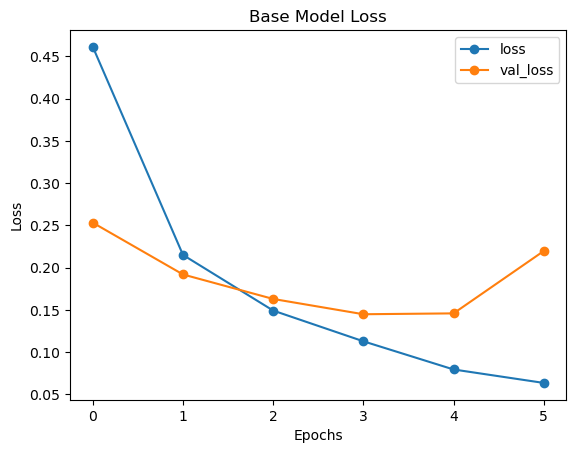

In [29]:
base_results[['loss','val_loss']].plot(marker='o')
plt.title('Base Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss');

### The base model shows signs of overfitting as the training loss shown by the blue line goes to 0, whereas the validation loss (orange line) starts to increase. This shows the model is learning too much noise from the data, so the variance is high, casuing to overfitting. 

### We have to explore other models and implement transfer learning to improve generalization.

In [30]:
image_shape

(180, 180, 3)

## False Predictions

### Since we shuffled the validation and test data, if we take the prediction on the validation images, then it will show incorrect results as it is compared with the shuffled labels, which are different with respect to the images.
### To show the false prediction, I have labelled it as a false prediction. To rectify this, we have to take the image and labels and save it into the list and then make the prediction.

In [161]:
false_predicted_classes = np.argmax(base_model.predict(val_data),axis=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step


In [162]:
print(classification_report(val_labels,false_predicted_classes,target_names=class_names))

              precision    recall  f1-score   support

       COVID       0.24      0.24      0.24       386
     Healthy       0.66      0.65      0.65       980
   Pneumonia       0.12      0.12      0.12       138

    accuracy                           0.50      1504
   macro avg       0.34      0.34      0.34      1504
weighted avg       0.50      0.50      0.50      1504



<br><br>

### To show the correct predictions we take the labels and images and save them into a list, which is then concatenated to merge these batches into a single numpy array. 
### Reference: https://stackoverflow.com/questions/73503162/tensorflow-accuracy-from-model-predict-does-not-match-final-epoch-val-accuracy-o

In [31]:
val_images =[]
val_labels = []
for images,labels in val_data:
    val_images.append(images.numpy())
    val_labels.append(labels.numpy())
    

2025-11-27 20:00:56.995665: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [34]:
val_images = np.concatenate(val_images)
val_labels = np.concatenate(val_labels)

### The base model predicts the probabilities of an image belonging to 3 classes. So to create a confusion matrix and classification report, we have to select the index with the highest probability, so we use np.argmax().

In [35]:
base_model_predicted_classes = np.argmax(base_model.predict(val_images),axis=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step


In [36]:
base_model_predicted_classes

array([2, 1, 2, ..., 1, 1, 1], shape=(1504,))

In [38]:
class_names

['COVID', 'Healthy', 'Pneumonia']

In [39]:
accuracy = round(100* accuracy_score(val_labels,base_model_predicted_classes),2)
print(f'Accuracy of the model is {accuracy} % ')

Accuracy of the model is 94.81 % 


### The classification allows us to evaluate the precision, recall and accuracy of each class.
### Precision is the accuracy of positive predictions, and recall is the ability of the model to find all the positive cases. 
### From the result, we can see that the model achieved 93% recall on COVID and 94% recall on Pneumonia, which means this model minimises the false negatives. This is very important in the medical domain because if the person with COVID is diagnosed as healthy, then he will spread the disease to other people, so it is better to have a high recall in the medical domain.
### There is a trade-off between precision and recall. Here, the precision of COVID is 90% that means model is conservative to capture more positive cases. 

In [40]:
print(classification_report(val_labels,base_model_predicted_classes,target_names=class_names))

              precision    recall  f1-score   support

       COVID       0.90      0.93      0.92       386
     Healthy       0.97      0.96      0.96       980
   Pneumonia       0.93      0.94      0.94       138

    accuracy                           0.95      1504
   macro avg       0.93      0.94      0.94      1504
weighted avg       0.95      0.95      0.95      1504



### Confusion matrix confirms this with 38 healthy cases predicted as COVID and 22 COVID cases as healthy. This is not good for the COVID prediction and leads to false negatives.

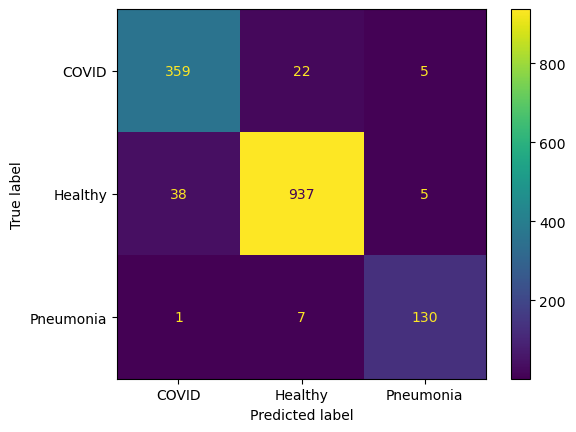

In [41]:
ConfusionMatrixDisplay.from_predictions(val_labels,base_model_predicted_classes,display_labels=class_names)

In [42]:
print(np.sum(val_labels!=base_model_predicted_classes))

78


In [43]:
print(round(100*np.sum(val_labels!=base_model_predicted_classes)/len(val_labels),2),'% ' )

5.19 % 


In [45]:
base_model.save('basemodel_lung_disease.keras')

<br><br>

# Improved model with Class weights and randomness
### Class Weights: https://stackoverflow.com/questions/66016844/imbalanced-image-dataset-tensorflow2

### To handle the class imbalance, we assign weights to the classes.
### We take the count of images for each class, then divide it by the number of classes times the count of the specific class to get the ratio of {0: 1.3968473451327434, 1: 0.4955847723704867, 2: 3.755390334572491} for COVID, healthy and Pneumonia, respectively.
### This is very important as the classes are very imbalanced, with the highest count as healthy. So, if we assign the weight, for example, Pneumonia is assigned with 3.7, that means when the model makes a mistake on Pneumonia, then the loss is multiplied by 3.7 times and forces the model to pay more attention to the Pneumonia cases than the Healthy. 

In [46]:
count_0 = 3616 #Covid
count_1 = 10192 # Healthy
count_2 = 1345 # Pneumonia
total = count_0+count_1+count_2

In [47]:
total

15153

In [48]:
weight_0 = (1/count_0)*(total/3.0)
weight_1 = (1/count_1)*(total/3.0)
weight_2 = (1/count_2)*(total/3.0)

In [49]:
class_weights = {
    0: weight_0,
    1:weight_1,
    2: weight_2
}

In [50]:
class_weights

{0: 1.3968473451327434, 1: 0.4955847723704867, 2: 3.755390334572491}

In [51]:
print('Class Weights')
print(f'COVID: {weight_0:.2f}\nHealthy: {weight_1:.2f}\nPneumonia: {weight_2:.2f}')

Class Weights
COVID: 1.40
Healthy: 0.50
Pneumonia: 3.76


<br><br>

## Data Augmentation
### Reference: https://stackoverflow.com/questions/66016844/imbalanced-image-dataset-tensorflow2

### When the data are similar, the model tries to memorise instead of learning, leading to overfitting. SO, we perform data augmentation to better generalise the model to new data.
### Random rotation of 0.03 rotates the images by 3% (10 degrees)
### Random Flip in horizontal direction mirrors the image left to right.
### Random Zoom randomly zooms in and out of the image by 10%.
### This allows the model to learn rather than memorise and overfit to the data. Also, in the clinic environment, patients might not always be still during the X-ray procedure, so this makes the model more robust. 

In [407]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.03),
    layers.RandomFlip('horizontal'),
    layers.RandomZoom(0.1)
],name='augmentation_block')

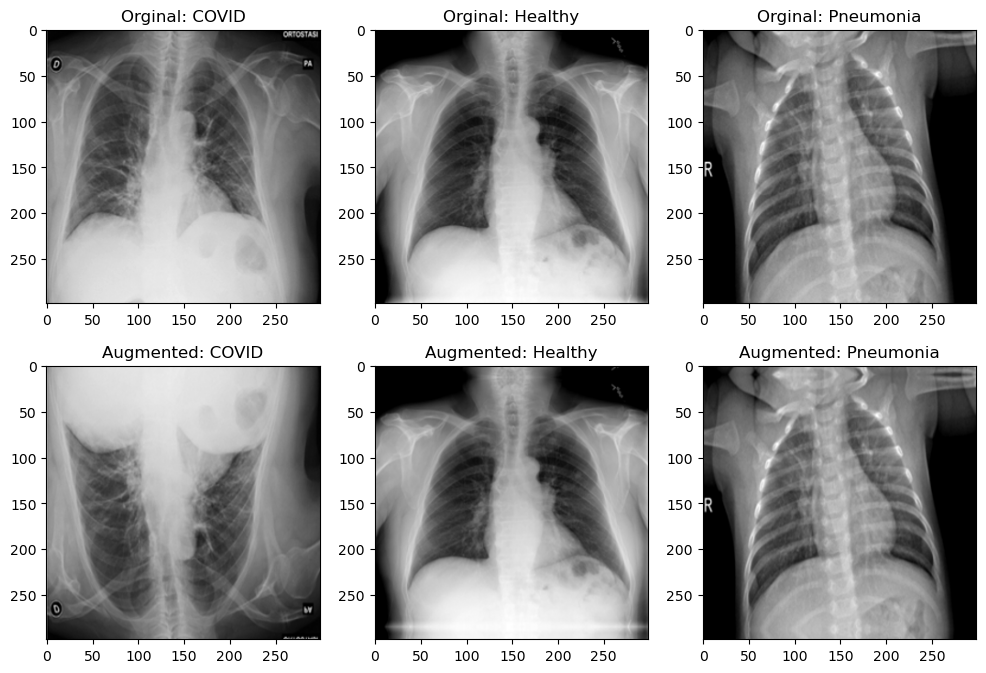

In [540]:
plt.figure(figsize=(12,8))

for i,category in enumerate(class_names):
    path = os.path.join(DATA_DIR,category)
    file_name = random.choice(os.listdir(path))
    img = mpimg.imread(os.path.join(path,file_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img,cmap='gray')
    plt.title(f'Orginal: {category}')

    aug_img = data_augmentation(tf.expand_dims(img,0),training=True)[0]

    plt.subplot(2,3,i+4)
    plt.imshow(aug_img/255.0,cmap='gray')
    plt.title(f'Augmented: {category}')

In [54]:
image_shape

(180, 180, 3)

### For the improved model, we also add data augmentation with random flip, rotation and random zoom.
### We rescale the data, then create a 2D convolutional layer with a filter of 64, followed by 128 and 256 neurons. Each Conv2D is followed by the max pooling layer of a 2X2 filter size.
### Then it is flattened into 1D, and a dense layer of 128 followed by 64 is applied with an activation function of rectified linear unit.
### This is followed by a final dense layer that outputs 3 neurons, one for each class, with softmax activation to output probabilities.
### Finally, the model is compiled using the Adam optimiser, and the loss is categorical crossentropy as it is a multi-class classification.

In [55]:
improved_model = Sequential()

improved_model.add(Input(shape=image_shape))

improved_model.add(layers.RandomFlip('horizontal'))
improved_model.add(layers.RandomRotation(0.1))
improved_model.add(layers.RandomZoom(0.1))

improved_model.add(layers.Rescaling(1./255))

improved_model.add(layers.Conv2D(filters=64,kernel_size=(3,3),padding='same',activation='relu'))
improved_model.add(layers.MaxPool2D(pool_size=(2,2)))

improved_model.add(layers.Conv2D(filters=128,kernel_size=(3,3),padding='same',activation='relu'))
improved_model.add(layers.MaxPool2D(pool_size=(2,2)))


improved_model.add(layers.Conv2D(filters=256,kernel_size=(3,3),padding='same',activation='relu'))
improved_model.add(layers.MaxPool2D(pool_size=(2,2)))


improved_model.add(layers.Flatten())
improved_model.add(layers.Dense(128,activation='relu'))
improved_model.add(layers.Dropout(0.5))

improved_model.add(layers.Dense(64,activation='relu'))
improved_model.add(layers.Dropout(0.5))


improved_model.add(Dense(3,activation='softmax'))

improved_model.compile(loss='sparse_categorical_crossentropy',
             optimizer='adam',
             metrics=['accuracy'])

In [56]:
improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 123904)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    15,859,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,239,107 (61.95 MB)

 Trainable params: 16,239,107 (61.95 MB)

 Non-trainable params: 0 (0.00 B)

### We can see there are ~16 Million trainable parameters in the improved model which is similar to the base model, but there are 2 key differences:
### 1. It includes the data augmentation for better generalisation.
### 2. Class weights are assigned to penalise the model for mistakes in class with higher weights. 

In [57]:
early_stopping = EarlyStopping(monitor='val_loss',
                              patience=5,
                              verbose=1,
                              restore_best_weights=True)

In [58]:
class_weights

{0: 1.3968473451327434, 1: 0.4955847723704867, 2: 3.755390334572491}

### Model is fitted with classweights and early stopping with validation data to calculate the validation loss and validation accuracy. 

In [61]:
start_time = time.time()

improved_results = improved_model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping]
)
end_time = time.time()
time_taken = (end_time-start_time)/60
print(f'\nTotal training time for improved model: {time_taken:.2f} minutes')

Epoch 1/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 313s 823ms/step - accuracy: 0.5039 - loss: 1.0631 - val_accuracy: 0.5838 - val_loss: 0.7778
Epoch 2/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 288s 760ms/step - accuracy: 0.5695 - loss: 0.6897 - val_accuracy: 0.4395 - val_loss: 0.8330
Epoch 3/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 292s 771ms/step - accuracy: 0.5898 - loss: 0.6456 - val_accuracy: 0.6057 - val_loss: 0.6941
Epoch 4/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 294s 774ms/step - accuracy: 0.6054 - loss: 0.6131 - val_accuracy: 0.6283 - val_loss: 0.7102
Epoch 5/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 292s 769ms/step - accuracy: 0.6239 - loss: 0.5816 - val_accuracy: 0.5559 - val_loss: 0.7510
Epoch 6/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 289s 763ms/step - accuracy: 0.6514 - loss: 0.5459 - val_accuracy: 0.6649 - val_loss: 0.6527
Epoch 7/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 289s 763ms/step - accuracy: 0.6793 - loss: 0.5000 - val_accuracy: 0.7952 - val_loss: 0.4622
Epoch 8/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 288s 759ms/step - accuracy: 0.7057 -

### The model ran for the entire 25 epochs, and the weights were restored from the 20th epoch. So, the model is trained for 25 more iterations because the model was still improving in the validation loss.
### We just fit the data again and run for 25 more epochs with the early stopping callback. This retraining is the continuation of the model that was trained for the previous 25 epochs. 

In [90]:
improved_model_extenstion = improved_model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 306s 807ms/step - accuracy: 0.8201 - loss: 0.3200 - val_accuracy: 0.8963 - val_loss: 0.2735
Epoch 2/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 321s 846ms/step - accuracy: 0.8359 - loss: 0.2921 - val_accuracy: 0.8637 - val_loss: 0.3229
Epoch 3/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 323s 851ms/step - accuracy: 0.8355 - loss: 0.3037 - val_accuracy: 0.8830 - val_loss: 0.3080
Epoch 4/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 319s 842ms/step - accuracy: 0.8370 - loss: 0.2927 - val_accuracy: 0.9116 - val_loss: 0.2436
Epoch 5/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 319s 841ms/step - accuracy: 0.8438 - loss: 0.2984 - val_accuracy: 0.8497 - val_loss: 0.3279
Epoch 6/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 321s 848ms/step - accuracy: 0.8539 - loss: 0.2797 - val_accuracy: 0.8963 - val_loss: 0.2537
Epoch 7/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 314s 828ms/step - accuracy: 0.8472 - loss: 0.2776 - val_accuracy: 0.8570 - val_loss: 0.3519
Epoch 8/25
379/379 ━━━━━━━━━━━━━━━━━━━━ 329s 868ms/step - accuracy: 0.8543 -

## Improved model evaluation

### The improved model showed the accuarcy of 90% on the validation data with loss of 25%.

In [91]:
improved_model.evaluate(val_data)

47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step - accuracy: 0.8934 - loss: 0.2755


[0.25603824853897095, 0.90625]

In [93]:
improved_model.metrics_names

['loss', 'compile_metrics']

In [97]:
improved_model_retrained = pd.DataFrame(improved_model.history.history)

In [113]:
improved_results

,accuracy,loss,val_accuracy,val_loss
0,0.535841,0.873128,0.583777,0.777772
1,0.577910,0.682163,0.439495,0.833027
2,0.603399,0.635352,0.605718,0.694127
3,0.624845,0.596962,0.628324,0.710151
4,0.633012,0.576378,0.555851,0.750950
5,0.659490,0.537417,0.664894,0.652672
6,0.686051,0.498703,0.795213,0.462171
7,0.701312,0.484225,0.735372,0.536146
8,0.707911,0.473998,0.735372,0.539668
9,0.728285,0.438895,0.761968,0.447526


In [114]:
improved_model_retrained

,accuracy,loss,val_accuracy,val_loss
0,0.822981,0.323924,0.896277,0.273465
1,0.830240,0.308254,0.863697,0.322864
2,0.832880,0.307486,0.882979,0.308041
3,0.837169,0.297022,0.911569,0.243607
4,0.837664,0.311188,0.849734,0.327878
5,0.852677,0.282777,0.896277,0.253668
6,0.852924,0.278561,0.857048,0.351883
7,0.854491,0.285076,0.883644,0.294119
8,0.848552,0.301912,0.881649,0.304210


In [100]:
full_history_df = pd.concat([improved_results, improved_model_retrained], ignore_index=True)

In [101]:
full_history_df

,accuracy,loss,val_accuracy,val_loss
0,0.535841,0.873128,0.583777,0.777772
1,0.577910,0.682163,0.439495,0.833027
2,0.603399,0.635352,0.605718,0.694127
3,0.624845,0.596962,0.628324,0.710151
4,0.633012,0.576378,0.555851,0.750950
5,0.659490,0.537417,0.664894,0.652672
6,0.686051,0.498703,0.795213,0.462171
7,0.701312,0.484225,0.735372,0.536146
8,0.707911,0.473998,0.735372,0.539668
9,0.728285,0.438895,0.761968,0.447526


### The loss and validation loss curve shows that from epoch 1 to 6, the loss drops significantly, whereas from epoch 7 to 20, the training loss decreases and the validation loss goes lower, reaching the lowest loss of 0.26 in epoch 20.
### In the later epoch beyond 20, the validation suddenly increases while the training loss continues to go down. This means the model started to memorise the data, leading to overfitting, and the model stopped training due to the early stopping callback and restores the weights from epoch 24. 

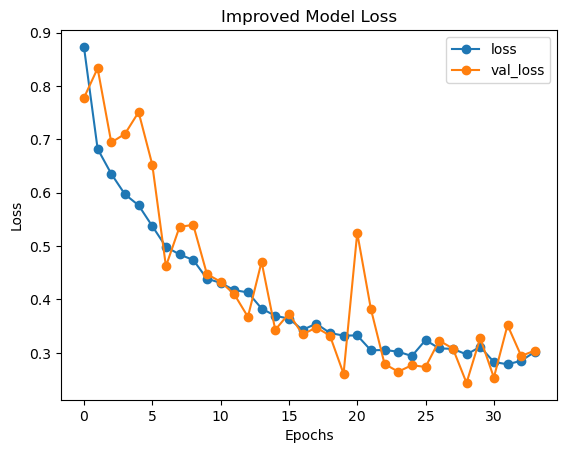

In [102]:
full_history_df[['loss','val_loss']].plot(marker='o')
plt.title('Improved Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss');

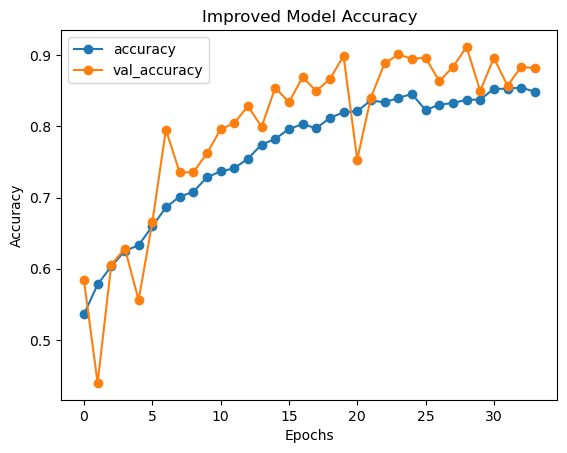

In [103]:
full_history_df[['accuracy','val_accuracy']].plot(marker='o')
plt.title('Improved Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [104]:
improved_model_predicted_classes = np.argmax(improved_model.predict(val_images),axis=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 230ms/step


In [105]:
improved_model_predicted_classes 

array([2, 0, 2, ..., 1, 1, 1], shape=(1504,))

In [106]:
accuracy = round(100* accuracy_score(val_labels,improved_model_predicted_classes ),2)
print(f'Accuracy of the model is {accuracy} % ')

Accuracy of the model is 91.09 % 


### With the integration of the data augmentation and class weights, the improved model is more robust and generalises the data better.
### The recall for Pneumonia is almost perfect, i.e., 0.99, which means the model is correctly idenfiying 99% of the Pneumonia cases. 
### While the precision for the COVID drops to 0.81, which signifies that the model is conservative, it is detecting more healthy cases as COVID. 
### Overall, the improved model is optimised to find more diseases and reduce the false negative.

In [107]:
print(classification_report(val_labels,improved_model_predicted_classes ,target_names=class_names))

              precision    recall  f1-score   support

       COVID       0.81      0.91      0.86       386
     Healthy       0.97      0.90      0.93       980
   Pneumonia       0.88      0.99      0.93       138

    accuracy                           0.91      1504
   macro avg       0.88      0.93      0.91      1504
weighted avg       0.92      0.91      0.91      1504



### From the classification report, we can see very few false negatives for the pneumonia cases, 1 case of pneumonia is classified as a healthy case. This means if a patient has pneumonia, then the model will almost perfectly flag it. 

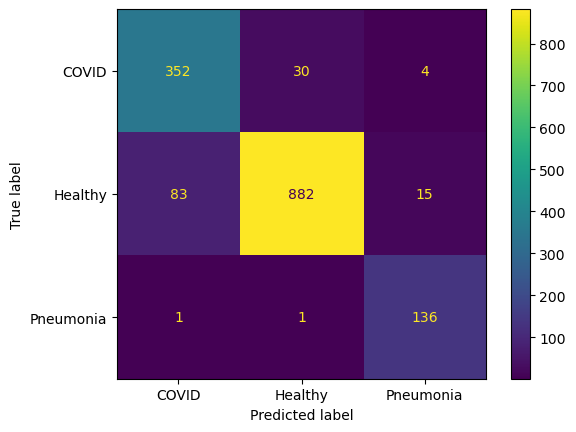

In [108]:
ConfusionMatrixDisplay.from_predictions(val_labels,improved_model_predicted_classes ,display_labels=class_names)

In [109]:
print(np.sum(val_labels!=improved_model_predicted_classes ))

134


In [110]:
print(round(100*np.sum(val_labels!=improved_model_predicted_classes)/len(val_labels),2),'% ' )

8.91 % 


In [112]:
improved_model.save('imporved_model_lung_disease.keras')

<br><br>

# Transfer Learning
### Transfer learning & fine-tuning: https://keras.io/guides/transfer_learning/

### Transfer learning is a technique to use a pretrained model to repurpose for a specific task.
### We use transfer learning because the model has been trained on a massive dataset, and it achieves higher accuracy with less computational cost compared to training the model from scratch. 

## VGG16

### VGG16 is a Convolutional Neural Network with 16 layers of depth with 3X3 filters.
### We use VGG16 as a feature extractor as it is robust, stable and outperforms other models while preventing overfitting.  

In [120]:
class_names

['COVID', 'Healthy', 'Pneumonia']

In [121]:
class_weights

{0: 1.3968473451327434, 1: 0.4955847723704867, 2: 3.755390334572491}

### We change the class weights to give more importance to COVID cases, as in the previous improved model, the Pneumonia cases were classified almost perfectly, but the COVID cases were not. So, we will increase the weight of covid class to 2 to penalise the loss of COVID cases more. 

In [122]:
new_class_weights = {
    0: 2.0,   #Covid
    1: 0.5,   #Healthy
    2: 3.75  # Pneumonia
}

### We load the VGG16 model and cut the top layer of the model, as it classifies 1000 different objects; we do not want the top layer, and we will replace it with our 3 classes (covid, healthy, and Pneumonia).
### we set the weights to imagenet as it is already trained to detect shapes, edges, textures from a large dataset of images. 
### Then we set the image_shape with size 180X180 pixels with 3 color channels.

In [123]:
vgg_base = VGG16(include_top=False,weights='imagenet',input_shape=(180,180,3))

### We freeze the base VGG model so as not upadate the weights, as we need its pretrained weights for feature extraction.  

In [124]:
vgg_base.trainable = False

### We create the model using the base vgg_model, and it expects the images in BGR and zero-centred, so we use preprocessing to transform the images.
### After adding the VGG_base model, we flatten to get the output in 1D and then feed it to the dense layer with 512 neurons, followed by 256, leading to the final output layer with 3 neurons and softmax activation. 

In [125]:
VGG_model = Sequential()

VGG_model.add(Input(shape=(180,180,3)))
VGG_model.add(layers.Lambda(tf.keras.applications.vgg16.preprocess_input))

VGG_model.add(vgg_base)

VGG_model.add(Flatten())
VGG_model.add(Dense(512,activation='relu'))
VGG_model.add(layers.Dropout(0.5))

VGG_model.add(Dense(256,activation='relu'))
VGG_model.add(layers.Dropout(0.5))

VGG_model.add(layers.Dense(3,activation='softmax'))

VGG_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                       metrics =['accuracy'])

### The summary of the model shows around 21 million total parameters, of which 14 M are non-trainable as we froze the base VGG model. 

In [126]:
VGG_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,400,899 (81.64 MB)

 Trainable params: 6,686,211 (25.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

### We set the early stopping callback to monitor the validation loss and have patience of 5, which means if the validation loss does not go down, then weight to check 5 more epochs before stopping the training. 
### If the training stops due to overfitting, then the model automatically restores the epoch with the lowest validation loss. 

In [135]:
early_stopping = EarlyStopping(monitor='val_loss',patience=5,
                              restore_best_weights=True,
                              verbose=1)

### To help the model achieve the best accuracy, we use a reduced learning rate, which monitors validation loss and reduces the learning rate by 20% until it reaches the learning rate of 0.0001.
### It allows the model to adjust how fast or slow the model learns. If the model has a very low learning rate, then it learns perfectly from the data but takes a longer time to train, and if the model has a higher learning rate, it doesnot learning from the data well. TO balance between the two, we use an adaptive learning rate.  

In [136]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.2,patience=2,min_lr=0.0001,verbose=1)

### We fit the VGG16 model with updated class weights and callbacks function of early stopping and reduce learning rate.  

In [137]:
start_time = time.time()

vgg_results = VGG_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    class_weight=new_class_weights,
    callbacks=[early_stopping,reduce_lr],
    batch_size=32
)
end_time = time.time()
time_taken = (end_time-start_time)/60
print(f'\nTotal training time for VGG16 model: {time_taken:.2f} minutes')

Epoch 1/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 688s 2s/step - accuracy: 0.8146 - loss: 0.3843 - val_accuracy: 0.8949 - val_loss: 0.2707 - learning_rate: 0.0010
Epoch 2/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 710s 2s/step - accuracy: 0.8406 - loss: 0.3388 - val_accuracy: 0.9149 - val_loss: 0.2382 - learning_rate: 0.0010
Epoch 3/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 681s 2s/step - accuracy: 0.8730 - loss: 0.3070 - val_accuracy: 0.9242 - val_loss: 0.2306 - learning_rate: 0.0010
Epoch 4/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 724s 2s/step - accuracy: 0.8848 - loss: 0.2968 - val_accuracy: 0.8876 - val_loss: 0.2773 - learning_rate: 0.0010
Epoch 5/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 736s 2s/step - accuracy: 0.8854 - loss: 0.2346 - val_accuracy: 0.9375 - val_loss: 0.1799 - learning_rate: 0.0010
Epoch 6/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 730s 2s/step - accuracy: 0.8772 - loss: 0.2213 - val_accuracy: 0.9382 - val_loss: 0.1735 - learning_rate: 0.0010
Epoch 7/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 698s 2s/step - accuracy: 0.8721 - loss: 0.

<br>

### The model was trained for approximately 6 hours, which shows the higher computational cost of the VGG16 model. The learning rate started from 0.001 and went down to 0.00001.
### The weights from the 25th epoch were restored by the callback, which had the lowest validation loss of 0.0975. 

<br><br>

### The model achieved an accuracy of 96.7% and a loss of 0.067 on the validation data.
### This shows the effectiveness of transfer learning. With the use of a pretrained model the accuracy went up, and the loss went down.

In [138]:
VGG_model.evaluate(val_data)

47/47 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.9682 - loss: 0.0961


[0.09711654484272003, 0.967420220375061]

In [140]:
VGG_model_results = pd.DataFrame(VGG_model.history.history)

In [141]:
VGG_model_results

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.820094,0.382352,0.894947,0.270739,0.0010
1,0.852842,0.343376,0.914894,0.238206,0.0010
2,0.878413,0.303547,0.924202,0.230576,0.0010
3,0.884764,0.299621,0.887633,0.277322,0.0010
4,0.887899,0.244904,0.937500,0.179891,0.0010
5,0.871237,0.232360,0.938165,0.173540,0.0010
6,0.869009,0.253409,0.940824,0.189762,0.0010
7,0.831807,0.293439,0.949468,0.160073,0.0010
8,0.833292,0.264663,0.923537,0.198806,0.0010
9,0.843603,0.250537,0.921543,0.202625,0.0010


### The loss and validation loss curves suggest that the training loss started from 0.38 and dropped to 0.10 in the epoch. Also, the validation started from 0.27 and dropped to 0.12. 
### Due to the dropout layers, the initial validation loss is lower than the training loss. Also, this curve shows no sign of overfitting, and the model has generalised the features rather than memorising the training data. The model has the lowest validation loss in epoch 25, which is restored by the early stopping callback. 

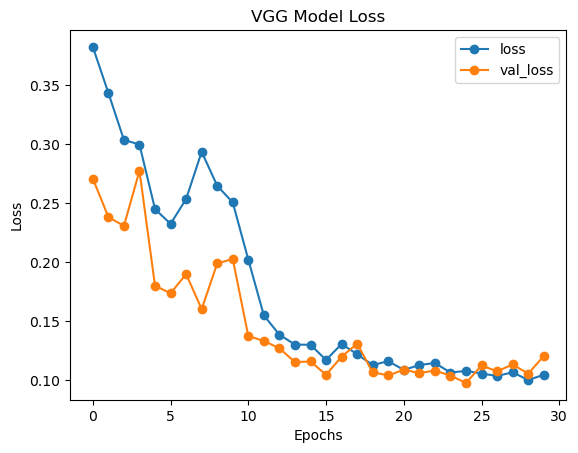

In [142]:
VGG_model_results[['loss','val_loss']].plot(marker='o')
plt.title('VGG Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss');

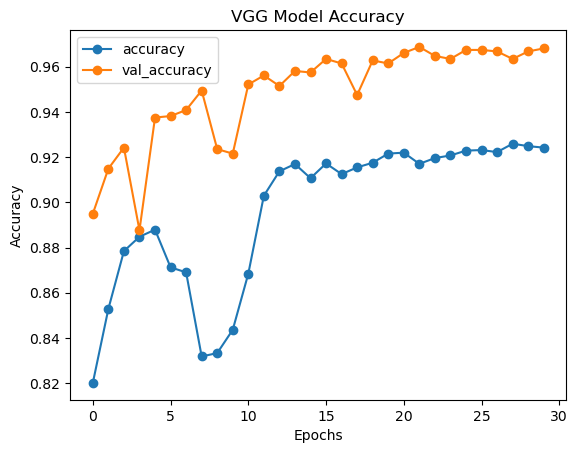

In [143]:
VGG_model_results[['accuracy','val_accuracy']].plot(marker='o')
plt.title('VGG Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [145]:
VGG_model_predicted_classes = np.argmax(VGG_model.predict(val_images),axis=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step


In [146]:
VGG_model_predicted_classes

array([2, 1, 2, ..., 1, 1, 1], shape=(1504,))

### The classification report suggests that the recall of COVID and Pneumonia is higher then 90%, 0.93 for COVID and 0.96 for Pneumonia. This shows model is detecting almost all cases of diseases, resulting in very low false negative.
### Also, we can see the precision and recall are almost perfect with an F1-score of 0.95 and 0.96 for COVID and Pneumonia. This shows the model is detecting almost all cases of COVID and Pneumonia while having very few false positives.
### This is exactly what is needed in the medical environment. There is still some room for improvement. We will experiment with other models to achieve better results. 


In [147]:
print(classification_report(val_labels,VGG_model_predicted_classes,target_names=class_names))

              precision    recall  f1-score   support

       COVID       0.96      0.93      0.95       386
     Healthy       0.97      0.98      0.98       980
   Pneumonia       0.96      0.96      0.96       138

    accuracy                           0.97      1504
   macro avg       0.97      0.96      0.96      1504
weighted avg       0.97      0.97      0.97      1504



### The confusion matrix suggests results with 14 healthy cases classified as COVID and 3 as Pneumonia, which shows the reason for having lower precision.

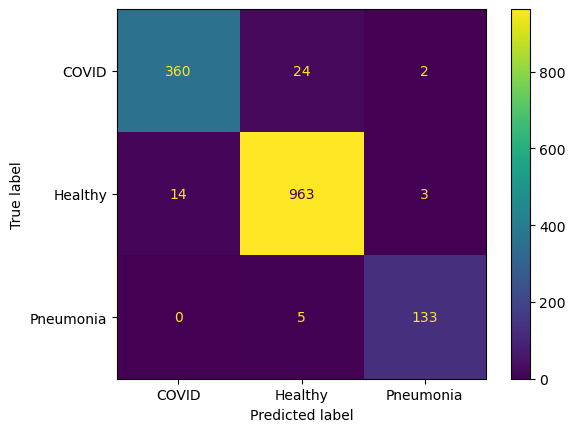

In [148]:
ConfusionMatrixDisplay.from_predictions(val_labels,VGG_model_predicted_classes,display_labels=class_names)

In [ ]:
VGG_model.save('vgg_model.keras')

In [149]:
print(np.sum(val_labels!=VGG_model_predicted_classes))

48


In [150]:
print(round(100*np.sum(val_labels!=VGG_model_predicted_classes)/len(val_labels),2),'% ' )

3.19 % 


In [151]:
VGG_model.save('vgg_model_lung_disease.keras')

## Testing on the final holdout test data 

### Similar to the validation data, the testing dataset has also been shuffled. So, we will manually extract the images and labels from the dataset. 

In [152]:
test_images =[]
test_labels = []
for images,labels in test_data:
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

2025-11-29 18:54:18.747791: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [153]:
test_images = np.concatenate(test_images)
test_labels = np.concatenate(test_labels)

In [154]:
VGG_model_predicted_classes_test = np.argmax(VGG_model.predict(test_images),axis=1)

48/48 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step


In [155]:
VGG_model_predicted_classes_test

array([1, 2, 0, ..., 2, 1, 0], shape=(1526,))

In [156]:
accuracy = round(100* accuracy_score(test_labels,VGG_model_predicted_classes_test),2)
print(f'Accuracy of the model is {accuracy} % ')

Accuracy of the model is 96.85 % 


### On the final holdout test data, the model shows a higher recall of 0.97 and 0.98 for COVID and Pneumonia. This is crucial in a pandemic scenario.
### Also, the precision of 0.93 on COVID shows that when the model predicts the person has COVID, 93% of the time it is correct. Remaining 7% are classified as healthy and Pheumonia cases. 

In [157]:
print(classification_report(test_labels,VGG_model_predicted_classes_test,target_names=class_names))

              precision    recall  f1-score   support

       COVID       0.93      0.97      0.95       379
     Healthy       0.98      0.97      0.98       993
   Pneumonia       0.96      0.98      0.97       154

    accuracy                           0.97      1526
   macro avg       0.96      0.97      0.96      1526
weighted avg       0.97      0.97      0.97      1526



### It only misclassifies 48 cases, as it is confused between the healthy cases and covid case. This is the result of the updated class weights, which penalise the wrong COVID cases 2 times higher than wrong healthy cases. This is important in the pandemic situation as it leads to lower false negatives. 


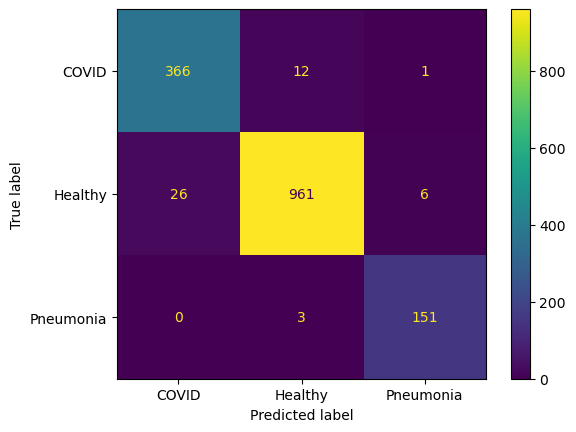

In [158]:
ConfusionMatrixDisplay.from_predictions(test_labels,VGG_model_predicted_classes_test,display_labels=class_names)

In [159]:
print(np.sum(test_labels!=VGG_model_predicted_classes_test))

48


In [160]:
print(round(100*np.sum(test_labels!=VGG_model_predicted_classes_test)/len(test_labels),2),'% ' )

3.15 % 


<br><br>

## ResNet50

### ResNet50 uses skip connections, which allow the features to skip some layers and rejoin in the later layers by feeding the output of one layer as an input to the other. This solves the problem with vanishing gradient and high parameter size of the VGG16 model. It is able to capture smaller details from the images. 

### We load the ResNet50  and cut the top layer of the model, as it classifies different objects; we do not want the top layer, and we will replace it with our 3 classes (COVID, healthy, and Pneumonia).
### we set the weights to imagenet as it is already trained to detect shapes, edges, textures from a large dataset of images. 
### Then we set the image_shape with size 180X180 pixels with 3 color channels.

In [178]:
resnet_base = ResNet50(weights='imagenet',include_top=False,input_shape=(180,180,3))

### We freeze the base with all 23+ million parameters not trained, and we want to train the head first. 

In [179]:
resnet_base.trainable = False

### We add the augmentation with randomflip and random rotation for better generalisation. 
### Also, we use the GlobalAveragePooling2D, which averages the feature map into a single vector instead of Flatten(), which keeps all spatial data.

In [180]:
resnet_model = Sequential()
resnet_model.add(layers.InputLayer(shape=(180,180,3)))
resnet_model.add(layers.RandomFlip("horizontal"))
resnet_model.add(layers.RandomRotation(0.1))
resnet_model.add(layers.RandomZoom(0.1))
resnet_model.add(layers.Lambda(tf.keras.applications.resnet50.preprocess_input))
resnet_model.add(resnet_base)

resnet_model.add(layers.GlobalAveragePooling2D())
resnet_model.add(Dropout(0.5))

resnet_model.add(Dense(3,activation='softmax'))

resnet_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics = ['accuracy'])

### The model has 23+ million parameters, but trainable parameters are only 6000. This is due to the GlobalAveragePooling that reduces the input to the dense layer. 

In [181]:
resnet_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_5 (RandomFlip)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_5               │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_5 (RandomZoom)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_4 (Lambda)               │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 6, 6, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [182]:
early_stopping = EarlyStopping(monitor='val_loss',patience=5,
                              restore_best_weights=True,
                              verbose=1)

### Reduce LROnPlateau: https://keras.io/api/callbacks/reduce_lr_on_plateau/

In [183]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.2,patience=2,min_lr=0.0001,verbose=1)

### We train the model with a frozen base. Our model will run for 30 epochs if the early stopping callback does not stop it, and we have class weights to deal with the imbalance in the dataset. 

In [184]:
start_time = time.time()

resnet_results1 = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    class_weight=new_class_weights,
    callbacks=[early_stopping,reduce_lr]
)
end_time = time.time()
time_taken = (end_time-start_time)/60
print(f'/n Total training time for VGG16 model: {time_taken:.2f} minutes')

Epoch 1/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 232s 605ms/step - accuracy: 0.6613 - loss: 0.8401 - val_accuracy: 0.8351 - val_loss: 0.4159 - learning_rate: 0.0010
Epoch 2/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 245s 647ms/step - accuracy: 0.8139 - loss: 0.3800 - val_accuracy: 0.8604 - val_loss: 0.3634 - learning_rate: 0.0010
Epoch 3/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 249s 657ms/step - accuracy: 0.8220 - loss: 0.3728 - val_accuracy: 0.8231 - val_loss: 0.4783 - learning_rate: 0.0010
Epoch 4/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.8198 - loss: 0.3577
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
379/379 ━━━━━━━━━━━━━━━━━━━━ 242s 639ms/step - accuracy: 0.8198 - loss: 0.3577 - val_accuracy: 0.7952 - val_loss: 0.4838 - learning_rate: 0.0010
Epoch 5/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 244s 645ms/step - accuracy: 0.8333 - loss: 0.3260 - val_accuracy: 0.8438 - val_loss: 0.3825 - learning_rate: 2.0000e-04
Epoch 6/30
379/379 ━━━━━━━━━━━━━━━━━━━━ 242s 639ms/step - accu

### The model was trained for 44 minutes, which is much faster than the VGG16 model. Also, the early stopping callback stops the training at epoch 6 with a lowest validation loss of 0.2983. 

In [185]:
resnet_model.save('resnet_frozen_model_lung_disease.keras')

### The accuracy of the model on validation data is 88%, which is much lower compared to the previous models. 

In [186]:
resnet_model.evaluate(val_data)

47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 553ms/step - accuracy: 0.8849 - loss: 0.2894


[0.29830828309059143, 0.883643627166748]

In [187]:
resnet_model_frozen_results = pd.DataFrame(resnet_results1.history)

In [188]:
resnet_model_frozen_results

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.728203,0.613433,0.835106,0.415938,0.0010
1,0.819434,0.374853,0.860372,0.363399,0.0010
2,0.820589,0.378020,0.823138,0.478274,0.0010
3,0.824796,0.360042,0.795213,0.483839,0.0010
4,0.837004,0.334002,0.843750,0.382455,0.0002
5,0.844758,0.325728,0.882314,0.298302,0.0002
6,0.846243,0.315692,0.825133,0.403356,0.0002
7,0.845088,0.312839,0.850399,0.349948,0.0002
8,0.848305,0.315310,0.842420,0.368240,0.0001
9,0.851192,0.306343,0.858378,0.335948,0.0001


### The training loss started from 0.85 and dropped to 0.29 in epoch 11; the validation loss dropped to 0.29.
### Both curves follow each other closely, which means there is no overfitting. But the model stopped training on the 11 epoch and restored the weight from the 6th epoch, which means it stopped improving as it is frozen. 
### So, to get higher accuracy, we will unfreeze and train the unfrozen ResNet model. 

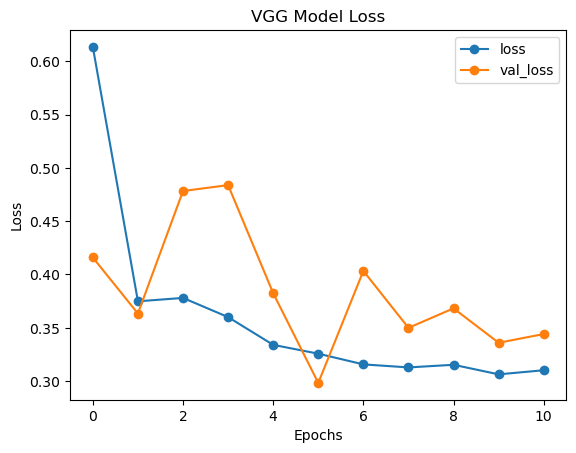

In [189]:
resnet_model_frozen_results[['loss','val_loss']].plot(marker='o')
plt.title('VGG Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss');

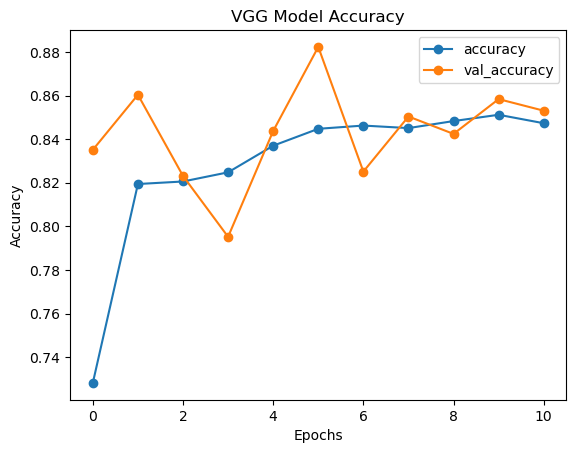

In [190]:
resnet_model_frozen_results[['accuracy','val_accuracy']].plot(marker='o')
plt.title('VGG Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [192]:
resnet_model_frozen_predicted_classes = np.argmax(resnet_model.predict(val_images),axis=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 560ms/step


In [193]:
resnet_model_frozen_predicted_classes

array([2, 1, 2, ..., 1, 1, 0], shape=(1504,))

### The classification report suggests that the model has very low precision in COVID (0.74) and pneumonia (0.82). That means when the model predicts the patient has COVID, 26% of the time it is incorrect.
### Similar results on the recall of healthy cases, it shows a recall of 0.86, which means it has a false postive of 14%. 

In [194]:
print(classification_report(val_labels,resnet_model_frozen_predicted_classes,target_names=class_names))

              precision    recall  f1-score   support

       COVID       0.74      0.90      0.81       386
     Healthy       0.96      0.86      0.91       980
   Pneumonia       0.82      0.96      0.89       138

    accuracy                           0.88      1504
   macro avg       0.84      0.91      0.87      1504
weighted avg       0.89      0.88      0.88      1504



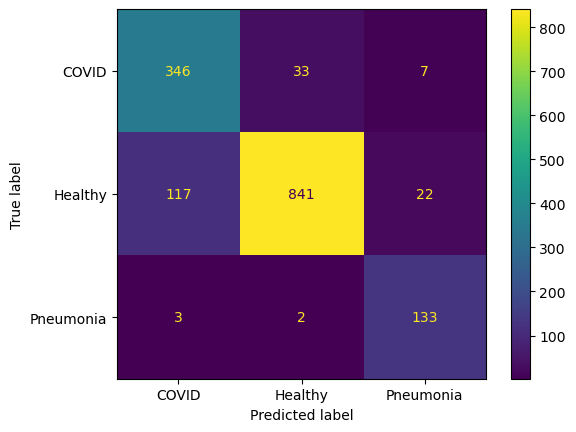

In [195]:
ConfusionMatrixDisplay.from_predictions(val_labels,resnet_model_frozen_predicted_classes,display_labels=class_names)

## Fine-Tuning
### https://keras.io/guides/transfer_learning/

### We give much higher importance to the COVID cases as we do not want the false negatives. 

In [196]:
changed_class_weights = {0: 4.0, 1:0.3, 2:3.75}

In [201]:
changed_class_weights

{0: 4.0, 1: 0.3, 2: 3.75}

### We set all the layers of the ResNet50 to trainable.
### Then we set the bottom 140 layers, from 0-140, to frozen, as the model has already been trained to detect basic features like lines and textures. 
### We set the rest of the layers from 140-175 to unfreeze, so we can train them.

In [197]:
resnet_base.trainable = True

In [198]:
for layer in resnet_base.layers[:140]:
    layer.trainable = False

In [199]:
print(f" {len(resnet_base.layers)}")

 175


### We compile the model without modifying the pre-trained weights.
### We set the learning rate to 0.00001 to change the weights of the pretrained model gently. 

In [200]:
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### We fit the model to run for 10 epochs. Initially, the model achieves a validation accuracy of 0.87, which then drops to 0.84 and again rises to 0.90.

In [202]:
start_time = time.time()

resnet_results2 = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,                  
    class_weight=changed_class_weights,
    callbacks=[early_stopping]
)

end_time = time.time()
print(f'Phase 2 time: {(end_time - start_time) / 60:.2f} minutes')

Epoch 1/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 0.6042 - loss: 0.5972 - val_accuracy: 0.8703 - val_loss: 0.3696
Epoch 2/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 372s 981ms/step - accuracy: 0.7900 - loss: 0.3209 - val_accuracy: 0.8418 - val_loss: 0.4471
Epoch 3/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 356s 939ms/step - accuracy: 0.8223 - loss: 0.2636 - val_accuracy: 0.8245 - val_loss: 0.4941
Epoch 4/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.8451 - loss: 0.2201 - val_accuracy: 0.8723 - val_loss: 0.3663
Epoch 5/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 404s 1s/step - accuracy: 0.8560 - loss: 0.1955 - val_accuracy: 0.8896 - val_loss: 0.3058
Epoch 6/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.8711 - loss: 0.1816 - val_accuracy: 0.8531 - val_loss: 0.3886
Epoch 7/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 378s 998ms/step - accuracy: 0.8876 - loss: 0.1470 - val_accuracy: 0.9023 - val_loss: 0.2565
Epoch 8/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 378s 999ms/step - accuracy: 0.8989 - loss: 0.136

### The unfrozen model trained for 10 epochs and early stopping restored the weights from epoch 7 with the lowest validation loss of 0.2565. 

### The evaluation of the model on training data suggest 89.7% accuracy and a validation loss of 0.26. Which is 1.5% increase in accuracy compared to the frozen model. 

In [203]:
resnet_model.evaluate(val_data)

47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 575ms/step - accuracy: 0.8998 - loss: 0.2493


[0.2678729295730591, 0.897606372833252]

In [204]:
resnet_model_tuned_results = pd.DataFrame(resnet_results2.history)

In [205]:
resnet_model_tuned_results

,accuracy,loss,val_accuracy,val_loss
0,0.699167,0.455440,0.870346,0.369600
1,0.802689,0.309807,0.841755,0.447110
2,0.823641,0.262305,0.824468,0.494142
3,0.853007,0.219101,0.872340,0.366276
4,0.866535,0.189659,0.889628,0.305787
5,0.875856,0.180623,0.853059,0.388600
6,0.890621,0.157065,0.902261,0.256543
7,0.899695,0.148205,0.903590,0.285048
8,0.907201,0.130142,0.894947,0.285229
9,0.916440,0.125109,0.897606,0.281023


### The training loss drops from 0.45 to 0.12 on the 10th epoch.
### The validation loss is unstable, which goes down to 0.25 and rises to 0.28.
### This is the sign of overfitting. After the 6th epoch, the model started to memorise the training data instead of learning from it. So, the weights were restored from the 7th epoch. 

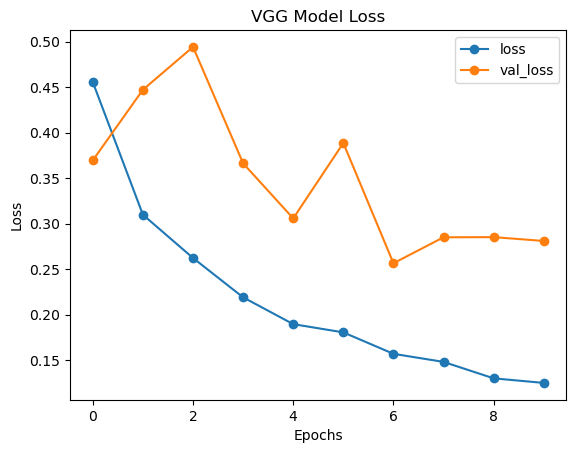

In [206]:
resnet_model_tuned_results[['loss','val_loss']].plot(marker='o')
plt.title('VGG Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss');

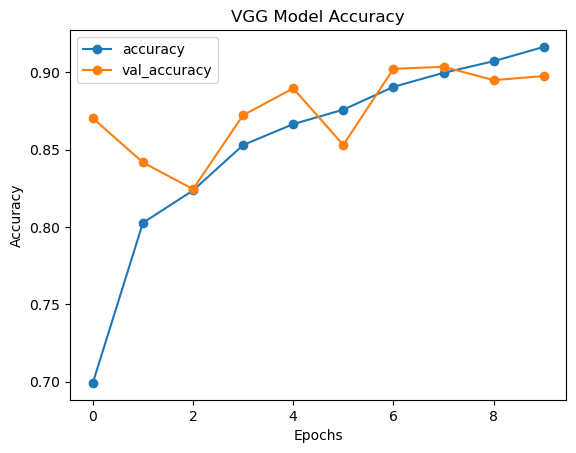

In [207]:
resnet_model_tuned_results[['accuracy','val_accuracy']].plot(marker='o')
plt.title('VGG Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

In [208]:
resnet_model_tuned_predicted_classes = np.argmax(resnet_model.predict(val_images),axis=1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 564ms/step


In [209]:
resnet_model_tuned_predicted_classes

array([2, 1, 2, ..., 1, 1, 0], shape=(1504,))

In [210]:
accuracy = round(100* accuracy_score(val_labels,resnet_model_tuned_predicted_classes),2)
print(f'Accuracy of the model is {accuracy} % ')

Accuracy of the model is 90.16 % 


### The classification report of the ResNet model suggests that it has high recall of 0.98 and 0.96 on the COVID and Pneumonia data. This is good as the model does not miss most of these cases, leading to low false negatives. 
### However, the precision of 0.76 on covid suggest that the model is conservative, and it is 24% of the time when it suggests it is covid case.
### This shows the model is confusing between the covid cases and healthy cases.

In [211]:
print(classification_report(val_labels,resnet_model_tuned_predicted_classes,target_names=class_names))

              precision    recall  f1-score   support

       COVID       0.76      0.98      0.85       386
     Healthy       0.99      0.86      0.92       980
   Pneumonia       0.90      0.96      0.93       138

    accuracy                           0.90      1504
   macro avg       0.88      0.93      0.90      1504
weighted avg       0.92      0.90      0.90      1504



### The confusion matrix shows similar results with 121 healthy cases classified as COVID, which is a false positive. As we increase the class weights of COVID cases, we become more conservative to force the model to predict more false positives. 

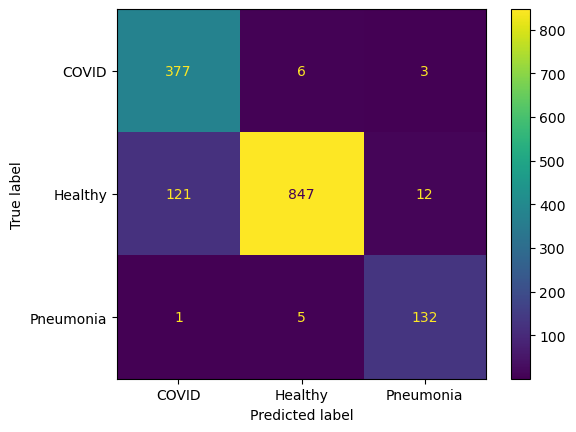

In [212]:
ConfusionMatrixDisplay.from_predictions(val_labels,resnet_model_tuned_predicted_classes,display_labels=class_names)

In [213]:
print(np.sum(val_labels!=resnet_model_tuned_predicted_classes))

148


In [214]:
print(round(100*np.sum(val_labels!=resnet_model_tuned_predicted_classes)/len(val_labels),2),'% ' )

9.84 % 


In [215]:
resnet_model.save('resnet_tuned_model_lung_disease.keras')

<br><br>

## Testing on the final holdout test data

In [234]:
test_images =[]
test_labels = []
for images,labels in test_data:
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

2025-11-30 20:11:10.032128: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [235]:
test_images = np.concatenate(test_images)
test_labels = np.concatenate(test_labels)

In [236]:
resnet_model_predicted_classes_test = np.argmax(resnet_model.predict(test_images),axis=1)

48/48 ━━━━━━━━━━━━━━━━━━━━ 25s 517ms/step


In [237]:
resnet_model_predicted_classes_test

array([1, 1, 0, ..., 2, 2, 2], shape=(1526,))

In [238]:
accuracy = round(100* accuracy_score(test_labels,resnet_model_predicted_classes_test),2)
print(f'Accuracy of the model is {accuracy} % ')

Accuracy of the model is 90.37 % 


In [239]:
print(classification_report(test_labels,resnet_model_predicted_classes_test,target_names=class_names))

              precision    recall  f1-score   support

       COVID       0.74      0.98      0.85       362
     Healthy       0.99      0.86      0.92      1016
   Pneumonia       0.90      0.98      0.94       148

    accuracy                           0.90      1526
   macro avg       0.88      0.94      0.90      1526
weighted avg       0.92      0.90      0.91      1526



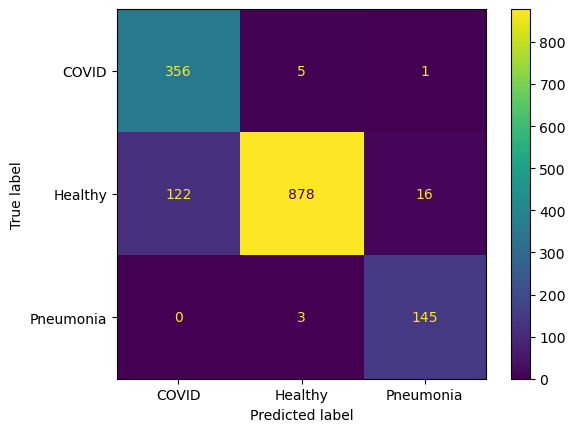

In [240]:
ConfusionMatrixDisplay.from_predictions(test_labels,resnet_model_predicted_classes_test,display_labels=class_names)

In [241]:
print(np.sum(test_labels!=resnet_model_predicted_classes_test))

147


In [242]:
print(round(100*np.sum(test_labels!=resnet_model_predicted_classes_test)/len(test_labels),2),'% ' )

9.63 % 


<br><br>

<br><br>

## Prediction with Threshold
### https://stackoverflow.com/questions/62396675/tensorflow-keras-prediction-threshold

### In situations like the COVID pandemic, we need to flag the cases even if there is a small chance of having it.
### Our prediction decides on the cases based on:
### COVID: 34%

### Healthy: 33% 

### Pneumonia: 33%

### But we can be hypersensitive towards the cases and decrease the threshold to 15% instead of 34%. 

In [586]:
def prediction_with_threshold(model,images,threshold=0.20):
    probs = model.predict(images,verbose=0)
    final_preds = []
    for p in probs:
        if p[0]>=threshold:
            final_preds.append(0) # COVID
        elif p[2]>=threshold:
            final_preds.append(2) # Pneumonia
        else:
            final_preds.append(np.argmax(p)) # Default to highest
    return np.array(final_preds)

In [231]:
safe_preds = prediction_with_threshold(resnet_model,val_images,threshold=0.15)

### Here by lowering the threshold to 15%. If the probability of the case is 15%, then it prioritises COVID first and classifies it as COVID.
### As we can see in the classification report, almost all the COVID cases have been detected by the model, leading to very few false negatives. 
### The trade-off of having higher recall is lower precision in COVID cases, as when the model detects a case as COVID only 64% time it is correct.

In [232]:
print(classification_report(val_labels,safe_preds,target_names=class_names))

              precision    recall  f1-score   support

       COVID       0.64      0.99      0.77       386
     Healthy       0.99      0.76      0.86       980
   Pneumonia       0.88      0.96      0.92       138

    accuracy                           0.84      1504
   macro avg       0.83      0.90      0.85      1504
weighted avg       0.89      0.84      0.85      1504



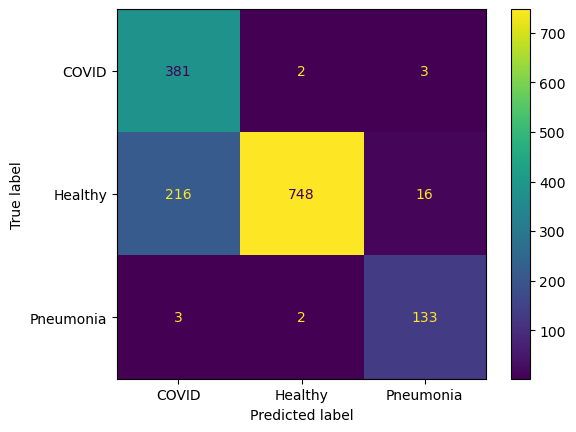

In [233]:
ConfusionMatrixDisplay.from_predictions(val_labels,safe_preds,display_labels=class_names)

<br>

## MobileNetV3
### Wang S, Ren J, Guo X (2024) A highaccuracy lightweight network model for X-ray image diagnosis: A case study of COVID detection. PLoS ONE 19(6): e0303049. https://doi.org/10.1371/journal.pone.0303049

### The use of the MobileNetV3 model is proposed in the paper "A high-accuracy lightweight network model for X-ray image diagnosis: A case study of COVID detection."
### The paper suggests the use of MobileNetV3, which is lightweight with less than 6 million parameters and applies specialised computer vision technique Contrast Limited Adaptive Histogram Equalisation (CLAHE) to enhance contrast and detail of the X-rays.

In [411]:
import cv2
import glob
from tqdm import tqdm

### The MobileNetV3 model requires the images in 224X224 pixels. 

In [412]:
source_dir = 'lung_dataset/'
destination_dir = 'Processed_Dataset/train'
img_size = (224,224)

In [413]:
class_names

['COVID', 'Healthy', 'Pneumonia']

### We create a new directory with 3 folders inside corresponding to each class in the dataset from orginal dataset.
### We use cv2.cvtColor to change the image to LAB colour, which is L (lightness), which contains only brightness and intensity information. The A and B contain the colour information. 
### The corresponding image is then passed through CLAHE to improve the contrast by dividing the image into 8X8 tiles, and if the tile is too noisy, it will not enhance that noise (clipLimit=2.0).
### The resulting image is then merged back into the BGR and saved into the destination folder.

In [414]:
for c in class_names:
    os.makedirs(os.path.join(destination_dir,c),exist_ok=True)

In [416]:
for c in class_names:
    files = glob.glob(os.path.join(source_dir,c,'*'))

    for f in tqdm(files):
        img = cv2.imread(f)
        if img is None:continue
        lab =cv2.cvtColor(img,cv2.COLOR_BGR2LAB)
        l,a,b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
        cl = clahe.apply(l)

        final = cv2.cvtColor(cv2.merge((cl,a,b)),cv2.COLOR_LAB2BGR)
        final = cv2.resize(final,img_size)

        save_path = os.path.join(destination_dir,c,os.path.basename(f))
        cv2.imwrite(save_path,final)

100%|██████████████████████████████████████| 1345/1345 [00:05<00:00, 253.43it/s]


### We can see an increase in contrast of the images through visualisation of orginal image and the enhanced image. 
### The enhanced model looks more detailed; the area inside the lung is clearly visible, which is where the model sees to detect cases of COVID and Pneumonia.

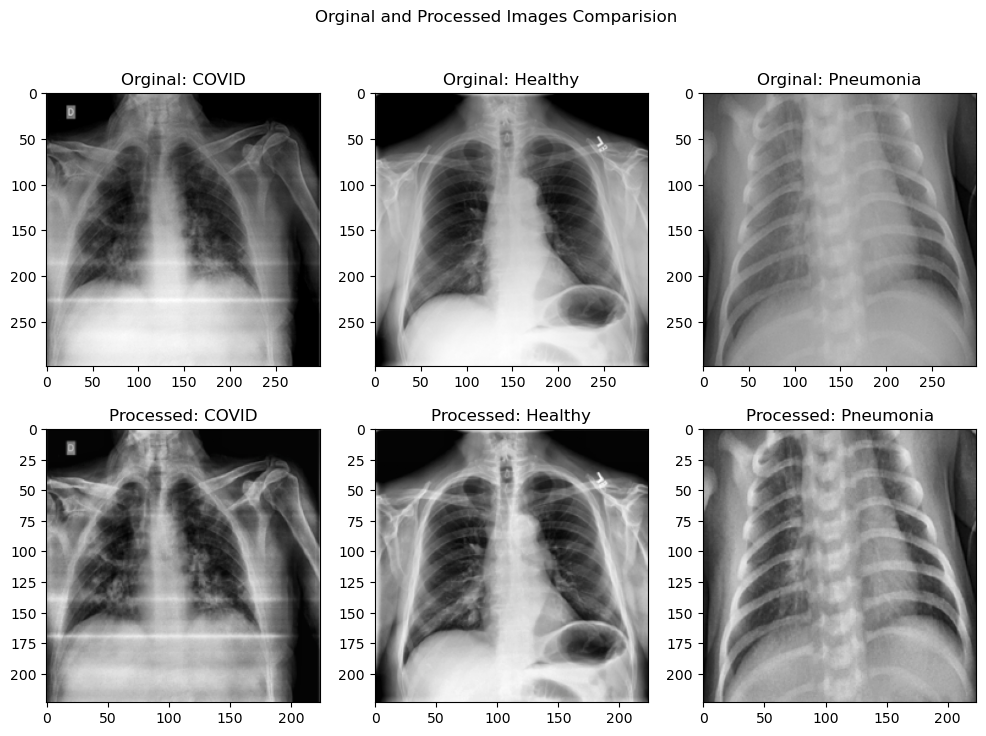

In [419]:
plt.figure(figsize=(12,8))
for i,category in enumerate(class_names):
    orginal_path = os.path.join('lung_dataset/',category)
    processed_path = os.path.join('Processed_Dataset/train',category)
    
    file_name = random.choice(os.listdir(orginal_path))
    
    org_img = mpimg.imread(os.path.join(orginal_path,file_name))
    proc_img= mpimg.imread(os.path.join(processed_path,file_name))

    plt.subplot(2,3,i+1)
    plt.imshow(org_img,cmap='gray')
    plt.title(f'Orginal: {category}')

    plt.subplot(2,3,i+4)
    plt.imshow(proc_img,cmap='gray')
    plt.title(f'Processed: {category}')

    

plt.suptitle('Orginal and Processed Images Comparision');

In [421]:
destination_dir

'Processed_Dataset/train'

In [422]:
img_size

(224, 224)

### We load the enhanced dataset into train and validation with an 80:20 split.
### We set the image size to match the MobileNetV3 requirement of 224X224.
### we also set the label mode to categorical because the model expects one-hot encoded vectors [0,0,1]. As we are using label smoothing in the later section.


In [446]:
proc_train_data = image_dataset_from_directory(
    destination_dir,validation_split=0.2,subset='training',seed=101,
    image_size=img_size,batch_size=32,label_mode='categorical'
)

Found 15153 files belonging to 3 classes.
Using 12123 files for training.


In [447]:
proc_val_data = image_dataset_from_directory(
    destination_dir,validation_split=0.2,subset='validation',seed=101,
    image_size=img_size,batch_size=32,label_mode='categorical'
)

Found 15153 files belonging to 3 classes.
Using 3030 files for validation.


### For the data augmentation, we set the random flip, random rotation, random zoom and random contrast. Since the model is more sensative so, we keep the random rotation to 3%. 

In [448]:
data_aug = Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.03),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

### We apply the data augmentation on the training images, and the validation images are clean as they are for testing. 
### Also, to optimise the processing we use num_parallel_calls, which helps TensorFlow to know the status of the CPU and GPU core and make efficient use of them.

In [449]:
train_ds = proc_train_data.map(lambda x,y: (data_aug(x),y),
                              num_parallel_calls=tf.data.AUTOTUNE)

val_ds = proc_val_data.map(lambda x,y: (x,y),
                          num_parallel_calls=tf.data.AUTOTUNE)

In [431]:
proc_train_data.class_names

['COVID', 'Healthy', 'Pneumonia']

In [434]:
class_weights

{0: 1.3968473451327434, 1: 0.4955847723704867, 2: 3.755390334572491}

### We define the base mobile_net model with MobileNetV3Large, which is optimised for higher accuracy while being efficient. 
### we remove the top layer to include our 3-class head. 

In [450]:
mobile_net_base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=(224,224,3),include_top=False,weights='imagenet'
)

### We unfreeze the full model and use a low learning rate to train the entire model.

In [451]:
mobile_net_base_model.trainable = True

### we use GlobalAveragePooling2D instead of flatten to make it more efficient. And set the dropout to 0.3 to prevent overfitting. 

In [452]:
mobile_model = Sequential([
    mobile_net_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(3,activation='softmax')
])

In [453]:
from tensorflow.keras import optimizers

### We use Adam optimiser with a learning rate of 0.00001. As we unfroze the whole model, this will slowly update the weights.
### Also, label smoothing is added, which prevents the model from being overconfident and allows for better generalisation on unseen data.
### Without Smoothing: Target = [1, 0, 0] vs. With Smoothing: Target = [0.93, 0.03, 0.03]
### We also add recall as a metric that will be seen while training. Since recall is important to detect the false negatives. 

In [454]:
mobile_model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics = ['accuracy',tf.keras.metrics.Recall(name='recall')]
)

### The model uses approximately 3 million parameters for training, which is 40 times smaller than VGG16 model. 

In [455]:
mobile_model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 3)              │         2,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,999,235 (11.44 MB)

 Trainable params: 2,974,835 (11.35 MB)

 Non-trainable params: 24,400 (95.31 KB)

### We fit the model with training and validation datasets, which are processed for higher contrast. 
### We also include the class weights + lower learning rate and label smoothing.

In [456]:
start_time = time.time()

history = mobile_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

end_time = time.time()
print(f'Total Training time: {(end_time - start_time) / 60:.2f} minutes')

Epoch 1/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 336s 857ms/step - accuracy: 0.7835 - loss: 0.6481 - recall: 0.7327 - val_accuracy: 0.7904 - val_loss: 0.7613 - val_recall: 0.7571
Epoch 2/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 326s 859ms/step - accuracy: 0.9444 - loss: 0.3837 - recall: 0.9346 - val_accuracy: 0.8644 - val_loss: 0.5943 - val_recall: 0.8475
Epoch 3/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 328s 862ms/step - accuracy: 0.9617 - loss: 0.3558 - recall: 0.9553 - val_accuracy: 0.8795 - val_loss: 0.5274 - val_recall: 0.8653
Epoch 4/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 327s 861ms/step - accuracy: 0.9693 - loss: 0.3460 - recall: 0.9655 - val_accuracy: 0.8861 - val_loss: 0.5143 - val_recall: 0.8673
Epoch 5/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 325s 856ms/step - accuracy: 0.9796 - loss: 0.3277 - recall: 0.9775 - val_accuracy: 0.9271 - val_loss: 0.4478 - val_recall: 0.9165
Epoch 6/15
379/379 ━━━━━━━━━━━━━━━━━━━━ 340s 894ms/step - accuracy: 0.9805 - loss: 0.3251 - recall: 0.9775 - val_accuracy: 0.8353 - val_loss: 0.6010 -

### The model trained for 1 hours and 30 mintutes and restored the weight from 10 epoch which has the lowest validation loss of 0.3813

### In order for prediction on the validation data we have to preprocess the image pixels into range [-1,1]. so we use preprocessing input on images before predictions.

In [493]:
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

In [494]:
val_images =[]
val_labels = []
for images,labels in val_ds:
    processed_img = preprocess_input(images)
    val_images.append(processed_img.numpy())
    val_labels.append(labels.numpy())

In [495]:
val_images = np.concatenate(val_images)
val_labels = np.concatenate(val_labels)

### On the validation data model, achieve an accuracy of 95% and a recall of 95%, which is an amazing result considering the training time.
### Compared to the VGG16 model, it sacrifies 1.5% accuracy for a 40 times reduction in size and speed. 

In [461]:
mobile_model.evaluate(val_ds)

95/95 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.9544 - loss: 0.3773 - recall: 0.9501


[0.3813362121582031, 0.9514851570129395, 0.9452145099639893]

In [463]:
mobile_model_results = pd.DataFrame(mobile_model.history.history)

In [464]:
mobile_model_results

,accuracy,loss,recall,val_accuracy,val_loss,val_recall
0,0.870329,0.500959,0.842036,0.790429,0.761328,0.757096
1,0.952404,0.378128,0.943908,0.864356,0.594255,0.847525
2,0.965603,0.355889,0.960653,0.879538,0.527410,0.865347
3,0.971294,0.345005,0.967335,0.886139,0.514306,0.867327
4,0.980615,0.328808,0.978883,0.927063,0.447810,0.916502
5,0.982843,0.323731,0.981028,0.835314,0.601026,0.814521
6,0.986719,0.316198,0.985565,0.848845,0.562683,0.834653
7,0.990349,0.308957,0.989771,0.895710,0.480907,0.884488
8,0.991174,0.309369,0.990761,0.910231,0.453173,0.901320
9,0.989607,0.310063,0.988617,0.951485,0.381336,0.945215


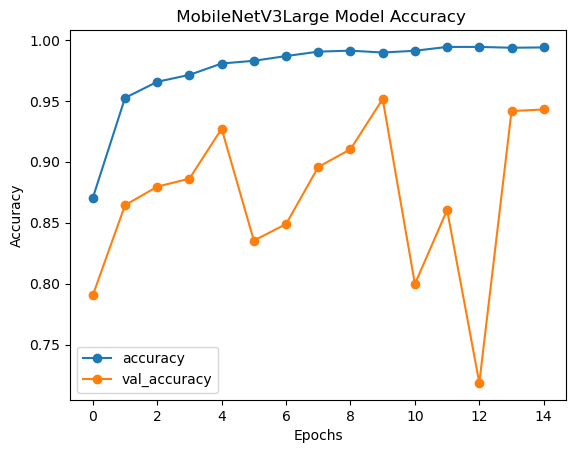

In [465]:
mobile_model_results[['accuracy','val_accuracy']].plot(marker='o')
plt.title(' MobileNetV3Large Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

### The training and validation loss curves suggest that the training loss declines to 0.3, whereas the validation loss bounces around 0.38 and 0.84.
### At epoch 13, the model starts to overfit. So the weights of epoch 10 are restored by the callback function.
### The model suggests that within 10 epoch model learned and then started to overfit. If there were no early stopping, then we would have settled with epoch 13 with 71% accuracy. But the callback function saved the model weight from epoch 10 with 95% accuracy. 

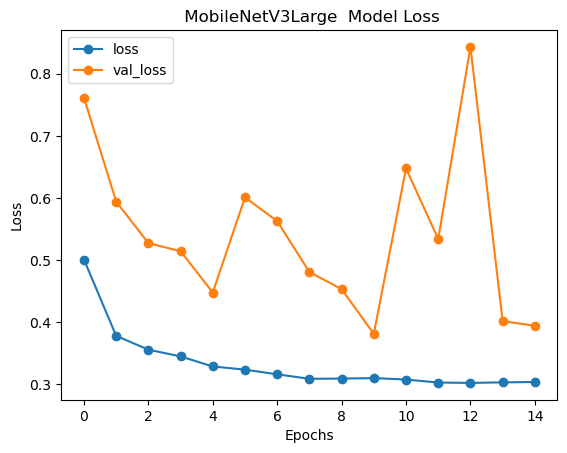

In [466]:
mobile_model_results[['loss','val_loss']].plot(marker='o')
plt.title(' MobileNetV3Large  Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss');

In [496]:
mobile_model_predicted_classes = np.argmax(mobile_model.predict(val_images),axis=1)

95/95 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step


In [502]:
mobile_model_predicted_classes

array([1, 1, 1, ..., 1, 1, 1], shape=(3030,))

In [505]:
y_true = np.argmax(val_labels,axis=1)

In [535]:
print(np.sum(y_true!=mobile_model_predicted_classes))

147


In [538]:
print(round(100*np.sum(y_true!=mobile_model_predicted_classes)/len(val_labels),2),'% ' )

4.85 % 


### The classification report suggests that the recall for Pneumonia is 100%, which means it can detect all the cases of Pneumonia.
### It is 97% recall in COVID detection, which means it caught 97% of COVID cases.
### Also, the precision of COVID is 0.91, which means if the model flags the case as covid 91% of the time, it is correct.
### Also, if the model says the person is healthy, 99% of the time it is correct.
### This is very important in medical cases, especially in panademic, where false negative is worst. 

In [506]:
print(classification_report(y_true,mobile_model_predicted_classes,target_names=class_names))

              precision    recall  f1-score   support

       COVID       0.91      0.97      0.94       747
     Healthy       0.99      0.94      0.96      1996
   Pneumonia       0.82      1.00      0.90       287

    accuracy                           0.95      3030
   macro avg       0.91      0.97      0.93      3030
weighted avg       0.96      0.95      0.95      3030



### The confusion matrix shows the model had 147 errors out of 3,030 predictions, which is an error rate of 4.85%.
### Most errors are seen when the healthy cases are flagged as COVID, which are false postive cases. 

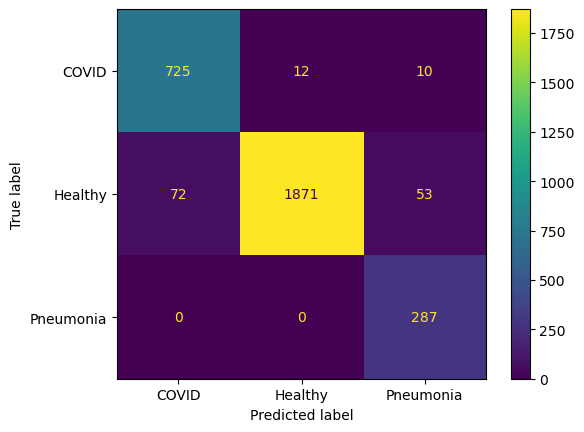

In [510]:
ConfusionMatrixDisplay.from_predictions(y_true,mobile_model_predicted_classes,display_labels=class_names)

In [526]:
mobile_model.save('mobilenet_v3_lung_disease.keras')

# Error Analysis

### The MobileNet achieve 95% accuracy, but there is 5% error. To visualise which images the model predicts incorrectly, we visualise the images that are predicted incorrectly. 

In [511]:
preds = mobile_model.predict(val_images)

95/95 ━━━━━━━━━━━━━━━━━━━━ 16s 164ms/step


In [515]:
pred_labels = np.argmax(preds,axis=1)

In [516]:
np.sum(y_true!=pred_labels)

np.int64(147)

### We get the indices of images whose prediction does not match the true labels.

In [517]:
incorrect = np.where(y_true!=pred_labels)[0]

In [518]:
incorrect

array([   3,    5,   60,   81,  107,  144,  145,  166,  172,  207,  287,
        336,  408,  416,  442,  472,  492,  502,  534,  576,  591,  600,
        602,  618,  633,  638,  645,  679,  695,  712,  739,  760,  762,
        767,  781,  782,  785,  812,  823,  828,  862,  879,  880,  920,
        936,  965,  972,  988, 1034, 1042, 1071, 1074, 1086, 1103, 1116,
       1188, 1234, 1247, 1258, 1304, 1311, 1312, 1328, 1365, 1381, 1383,
       1427, 1428, 1503, 1556, 1592, 1643, 1658, 1668, 1678, 1685, 1702,
       1746, 1748, 1752, 1768, 1772, 1816, 1837, 1855, 1863, 1881, 1897,
       1924, 1933, 1944, 1946, 1953, 1958, 2009, 2041, 2104, 2123, 2141,
       2160, 2179, 2210, 2259, 2261, 2266, 2282, 2291, 2307, 2325, 2363,
       2374, 2376, 2409, 2411, 2419, 2444, 2454, 2463, 2472, 2498, 2527,
       2577, 2580, 2589, 2591, 2606, 2637, 2672, 2703, 2704, 2723, 2726,
       2746, 2761, 2788, 2846, 2860, 2884, 2891, 2911, 2914, 2933, 2961,
       2984, 2990, 3006, 3015])

In [519]:
len(incorrect)

147

In [523]:
len(val_labels)

3030

### To see the confidence score, we get the maximum confidence from the array of 3 predictions. 

In [521]:
all_confidences = np.max(preds,axis=1)

### As we can see from the results most common errors are healthy cases classified as COVID cases. This happened because of the images and the class weights. We prefer to have false positives to having false negatives. 

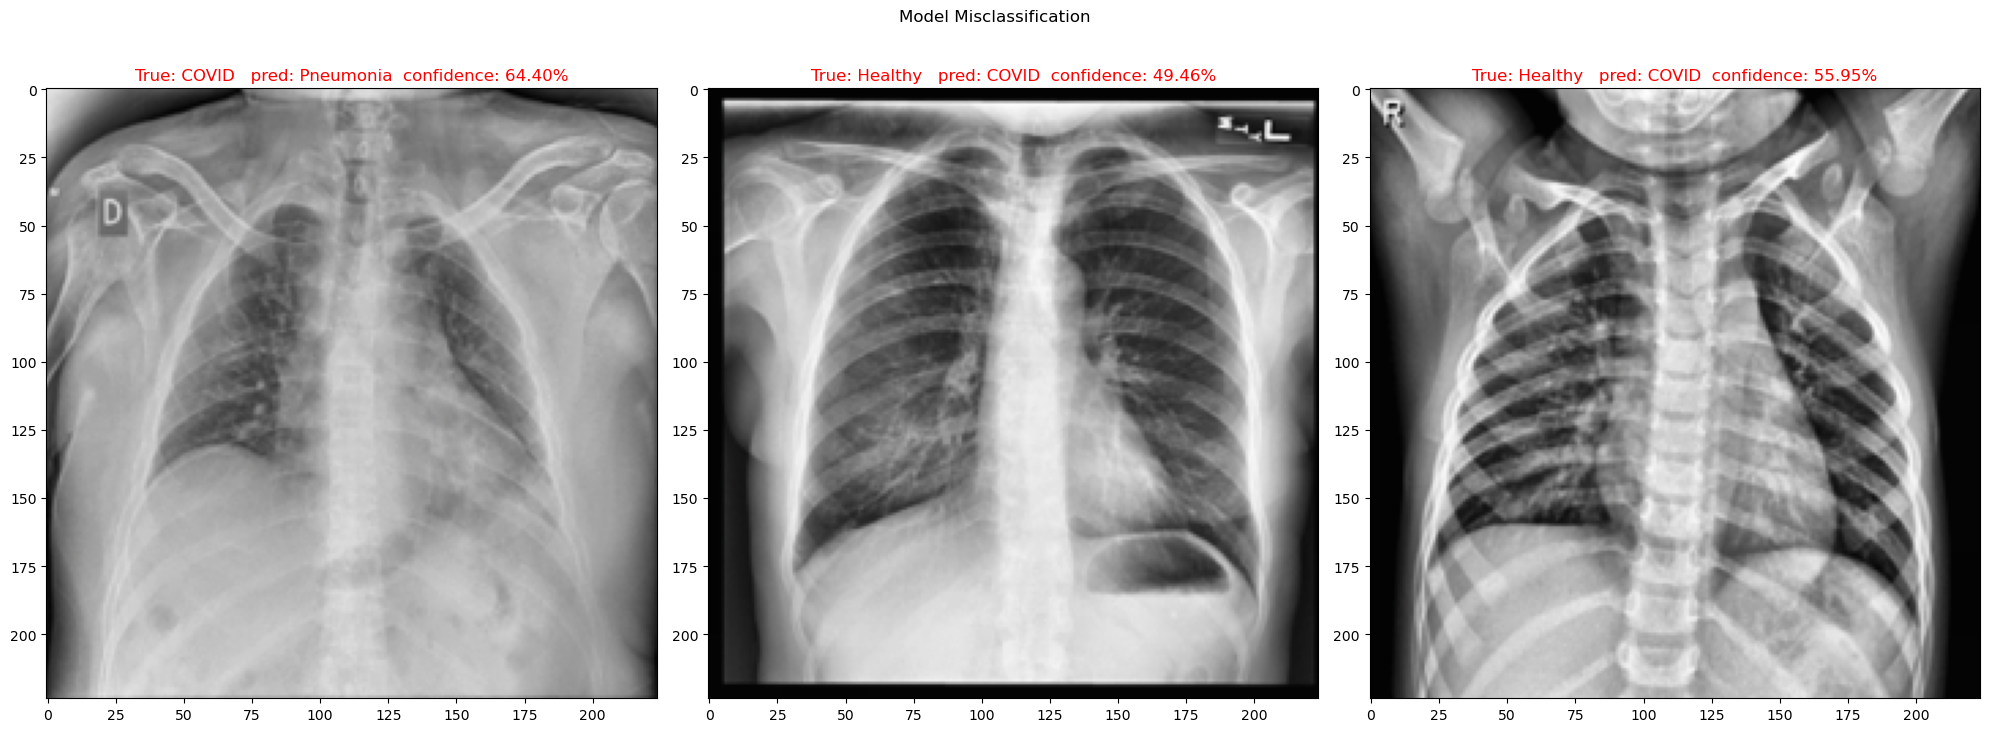

In [592]:
plt.figure(figsize=(20,8))
num_to_show = min(3,len(incorrect))
random_errors = np.random.choice(incorrect,num_to_show,replace=False)


for i,idx in enumerate(random_errors):
    ax = plt.subplot(1,3,i+1)
    img_display = val_images[idx]
    img_display = img_display/255.
    plt.imshow(img_display)

    true_name = class_names[y_true[idx]]
    pred_name = class_names[pred_labels[idx]]
    confidence = all_confidences[idx]

    plt.title(f'True: {true_name}   pred: {pred_name}  confidence: {confidence:.2%}',color='red')
    plt.tight_layout()


plt.suptitle(f'Model Misclassification');

<br><br>

# Deployment using Gradio
### https://www.gradio.app/4.44.1/guides/image-classification-in-tensorflow

### Deployment using the gradio allows the doctor to upload the image of the X-rays and then get the results if the patient has COVID, Pneumonia or is Healthy. 

In [7]:
import tensorflow as tf

In [11]:
import numpy as np

In [3]:
from tensorflow.keras.models import load_model

In [9]:
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

In [4]:
loaded_model = load_model('mobilenet_v3_lung_disease.keras')

In [2]:
import gradio as gr

In [13]:
class_names = ['COVID', 'Healthy', 'Pneumonia']

### We create a function which takes an image as input, resizes it to match what MobileNet expects.
### Then normalises pixels between [-1,1]
### And expand the dimension as the model expects individual images to be in the shape (1,244,244,3), and the uploaded image is (224,224,3)
### Then the model runs the predictions and flatten it and returns the dictionary with {'label':prediction}, e.g.: {'COVID':0.99}. 

In [5]:
def predict_lung_disease(image):
    image = tf.image.resize(image,(224,224))
    image_norm = preprocess_input(image)
    image = np.expand_dims(image_norm,axis=0)
    pred = loaded_model.predict(image).flatten()
    return {class_names[i]: float(pred[i]) for i in range(3)}

### For the gradio interface, we set the input UI that allows the user to upload an image and perform the prediction using the predict_lung_disease function and finally display the output to the user in terms of probabilities.  

In [14]:
interface = gr.Interface(
    fn = predict_lung_disease,
    inputs = gr.Image(label='Upload Chest X-ray'),
    outputs = gr.Label(num_top_classes=3,label='Diagnosis'),
    title= 'Lung Disease Prediction',
    description = 'Upload Chest X-ray to detect Covid, Pneumonia, or Healthy lungs.'
)

interface.launch(share=False)

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
